# IY021 – SVM vs Catch22+SVM on Experimental Time Series

**Goal:** Classify Msn2-mCherry steady-state time series by glucose environment using two approaches:
1. **Raw SVM (RBF)** – raw time series directly as features
2. **Catch22 + SVM (RBF)** – 22 canonical time-series features as input to SVM

**Data:** `EXP-25-IY008/4_transformed_exp_time_series/`

---

### TF structure of the experiments

Each experiment contains multiple yeast strains ("groups"), each expressing **Msn2-mCherry** (always the mCherry reporter) alongside a strain-specific **GFP-TF**. Classifications are only meaningful when comparing the **same strain** under different glucose conditions.

| Experiment | Glucose | group 1344 (Cat8-GFP) | group 1346 (Nrg1-GFP) | group 1347 (Rtg1-GFP) | Other groups |
|---|---|---|---|---|---|
| 19316 | **2%** | ✓ Cat8/Msn2 | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |
| 19554 | 0.01% | — | — | — | 900=Mig1/Msn2, 756/903=unknown |
| 19566 | **0.1%** | ⚠️ TF uncertain | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |
| 20213 | **0.01%** | ✓ Cat8/Msn2 | ✓ Nrg1/Msn2 | ✓ Rtg1/Msn2 | — |

**Exclusions (with reason):**
- **19554 entirely**: Mig1 strain (group 900) is not present in other experiments; groups 756/903 have unidentified TFs
- **19566 / group 1344**: TF identity ambiguous (absent from OMERO metadata for this experiment)

**Included for 3-way classification (2% vs 0.1% vs 0.01%):**  
Groups **1346 (Nrg1)** and **1347 (Rtg1)** — the only strains present across all 3 glucose conditions.

In [10]:
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycatch22
from pathlib import Path
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm.auto import tqdm

sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")

RANDOM_STATE = 42
IY021_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY021")
DATA_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series")
np.random.seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

## 1. Load Data & Assign Environment Labels

In [11]:
# Verify TF mapping per experiment using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_OMID_MAP = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "19554": "19554_2020_12_06_steadystate_glucose_2w0p01_900m_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
}

print("TF mapping verification via get_exp_summary")
print("=" * 65)
for prefix, omid in _OMID_MAP.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump = summary_df["pump_contents"].values[0]
    print(f"\n{prefix}  pump={pump}")
    if not tf_df.empty:
        print(tf_df.to_string(index=False))
    else:
        print("  (no TF metadata)")

TF mapping verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORMATION:
• Pro

In [12]:
FILE_REGISTRY = {
    # --- 2% glucose (label 0) ---
    "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_mCherry_time_series":
        (0, "2%",   "Nrg1", "Msn2"),
    "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_mCherry_time_series":
        (0, "2%",   "Rtg1", "Msn2"),
    # --- 0.1% glucose (label 1) ---
    "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_mCherry_time_series":
        (1, "0.1%", "Nrg1", "Msn2"),
    "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_mCherry_time_series":
        (1, "0.1%", "Rtg1", "Msn2"),
    # --- 0.01% glucose (label 2) ---
    "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_mCherry_time_series":
        (2, "0.01%", "Nrg1", "Msn2"),
    "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_mCherry_time_series":
        (2, "0.01%", "Rtg1", "Msn2"),
}
# Exclusions (with reason):
#   19554 entirely  – Mig1-GFP (group 900) not comparable; groups 756/903 TF unknown
#   19566/group1344 – TF identity ambiguous (absent from OMERO metadata)
#   Cat8 (group1344 in 19316/20213) – only present in 2 of 3 conditions; excluded for balance

label_names = {0: "2% glucose", 1: "0.1% glucose", 2: "0.01% glucose"}
META_COLS   = ["id", "group", "experiment"]

all_X, all_y, all_strain = [], [], []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    stem = csv_path.stem
    if stem not in FILE_REGISTRY:
        continue
    glucose_label, glucose_pct, gfp_tf, mcherry_tf = FILE_REGISTRY[stem]
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    ts = df[time_cols].values.astype(float)
    all_X.append(ts)
    all_y.extend([glucose_label] * len(ts))
    all_strain.extend([gfp_tf] * len(ts))
    print(f"  Loaded: {gfp_tf}-GFP/Msn2-mCherry @ {glucose_pct} glc  "
          f"({ts.shape[0]} cells × {ts.shape[1]} tp)")

# Files have different numbers of timepoints — truncate to the shortest
min_tp = min(ts.shape[1] for ts in all_X)
print(f"\nTruncating all series to {min_tp} timepoints (shortest file)")
all_X = [ts[:, :min_tp] for ts in all_X]

X_raw   = np.vstack(all_X)
y       = np.array(all_y,     dtype=int)
strains = np.array(all_strain)

print(f"Dataset: {X_raw.shape[0]} cells × {X_raw.shape[1]} timepoints")
for lbl, name in label_names.items():
    mask = y == lbl
    strain_counts = {s: int(np.sum(strains[mask] == s)) for s in np.unique(strains[mask])}
    print(f"  {lbl}: {name:15s} → {mask.sum():4d} cells  {strain_counts}")

  Loaded: Nrg1-GFP/Msn2-mCherry @ 2% glc  (84 cells × 128 tp)
  Loaded: Rtg1-GFP/Msn2-mCherry @ 2% glc  (78 cells × 126 tp)
  Loaded: Nrg1-GFP/Msn2-mCherry @ 0.1% glc  (231 cells × 135 tp)
  Loaded: Rtg1-GFP/Msn2-mCherry @ 0.1% glc  (200 cells × 117 tp)
  Loaded: Nrg1-GFP/Msn2-mCherry @ 0.01% glc  (231 cells × 105 tp)
  Loaded: Rtg1-GFP/Msn2-mCherry @ 0.01% glc  (275 cells × 89 tp)

Truncating all series to 89 timepoints (shortest file)
Dataset: 1099 cells × 89 timepoints
  0: 2% glucose      →  162 cells  {np.str_('Nrg1'): 84, np.str_('Rtg1'): 78}
  1: 0.1% glucose    →  431 cells  {np.str_('Nrg1'): 231, np.str_('Rtg1'): 200}
  2: 0.01% glucose   →  506 cells  {np.str_('Nrg1'): 231, np.str_('Rtg1'): 275}


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_mCherry_catch22_trace_overview.png


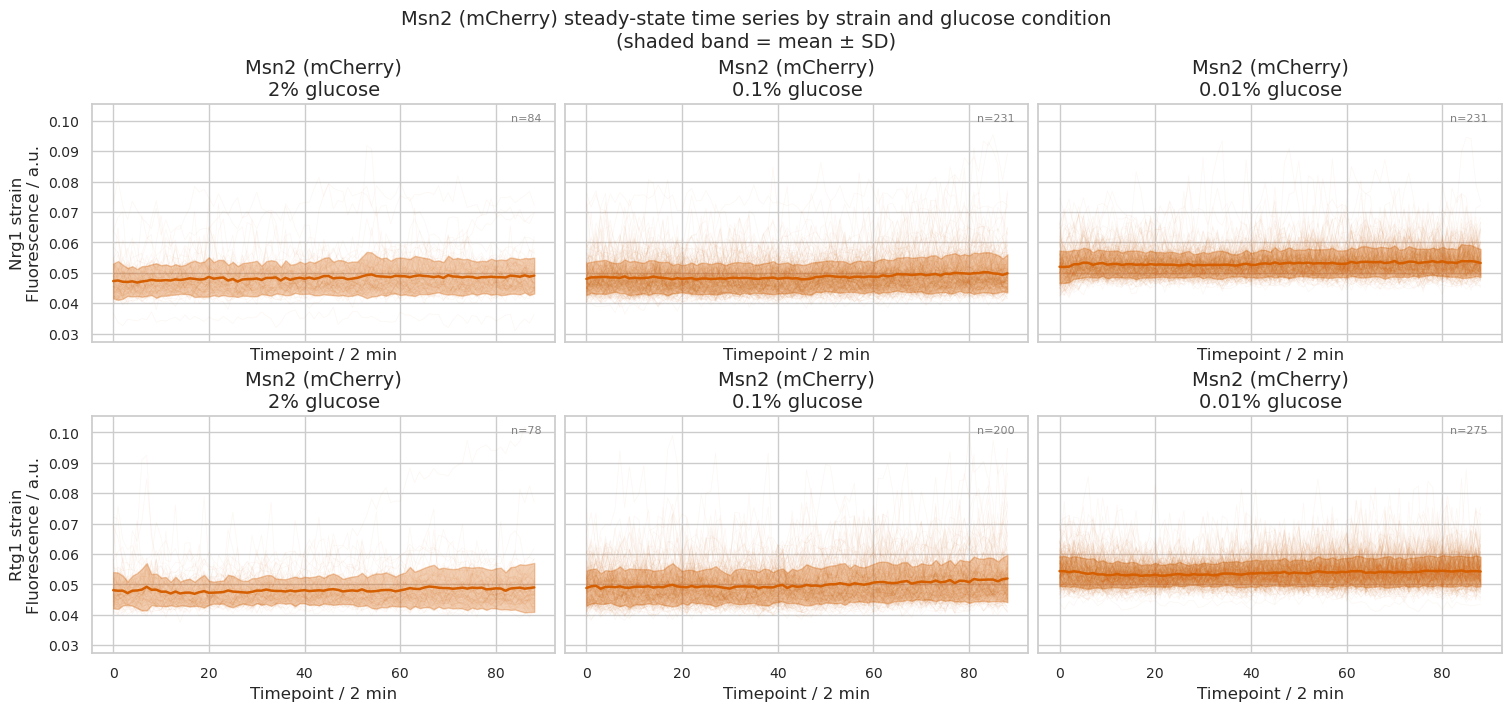

In [13]:
palette  = sns.color_palette("colorblind")
ch_color = palette[3]  # reddish — mCherry

tfs        = ["Nrg1", "Rtg1"]
conditions = sorted(label_names.keys())
n_tp       = X_raw.shape[1]
t_axis     = np.arange(n_tp)

fig, axes = plt.subplots(len(tfs), len(conditions),
                         figsize=(5 * len(conditions), 3.5 * len(tfs)),
                         sharey=True, sharex=True,
                         constrained_layout=True)

for row, tf in enumerate(tfs):
    for col, lbl in enumerate(conditions):
        ax    = axes[row][col]
        mask  = (y == lbl) & (strains == tf)
        X_sub = X_raw[mask]

        for trace in X_sub:
            ax.plot(t_axis, trace, color=ch_color, alpha=0.05, linewidth=0.5)

        if len(X_sub):
            mean = np.nanmean(X_sub, axis=0)
            sd   = np.nanstd(X_sub, axis=0)
            ax.plot(t_axis, mean, color=ch_color, linewidth=1.8)
            ax.fill_between(t_axis, mean - sd, mean + sd,
                            color=ch_color, alpha=0.3)

        ax.set_title(f"Msn2 (mCherry)\n{label_names[lbl]}", fontsize=14)
        ax.set_xlabel("Timepoint / 2 min", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{tf} strain\nFluorescence / a.u.", fontsize=12)
        ax.tick_params(labelsize=10)
        ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color="gray")

fig.suptitle("Msn2 (mCherry) steady-state time series by strain and glucose condition\n(shaded band = mean ± SD)",
             fontsize=14)
fig_path = IY021_DIR / "IY021_mCherry_catch22_trace_overview.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## 2. Preprocessing: NaN Handling, Balancing & Train/Test Split

In [ ]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from utils.processing.imputation import fill_nans

X_clean = fill_nans(X_raw)
print(f"NaN remaining after fill: {np.isnan(X_clean).sum()}")

# Balance classes by subsampling to minority class size using seeded RNG
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Minority class count: {min_count} → subsampling all classes to this size")

rng = np.random.default_rng(RANDOM_STATE)
balanced_idx = np.concatenate([
    rng.choice(np.where(y == lbl)[0], size=min_count, replace=False)
    for lbl in sorted(label_names)
])

X_bal = X_clean[balanced_idx]
y_bal = y[balanced_idx]

print(f"\nBalanced dataset: {X_bal.shape[0]} cells × {X_bal.shape[1]} timepoints")
for lbl, name in label_names.items():
    print(f"  Label {lbl} ({name}): {np.sum(y_bal == lbl)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bal
)
print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Train class counts: {np.bincount(y_train)}")
print(f"Test  class counts: {np.bincount(y_test)}")

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_mcherry_catch22_balanced_class_traces.png


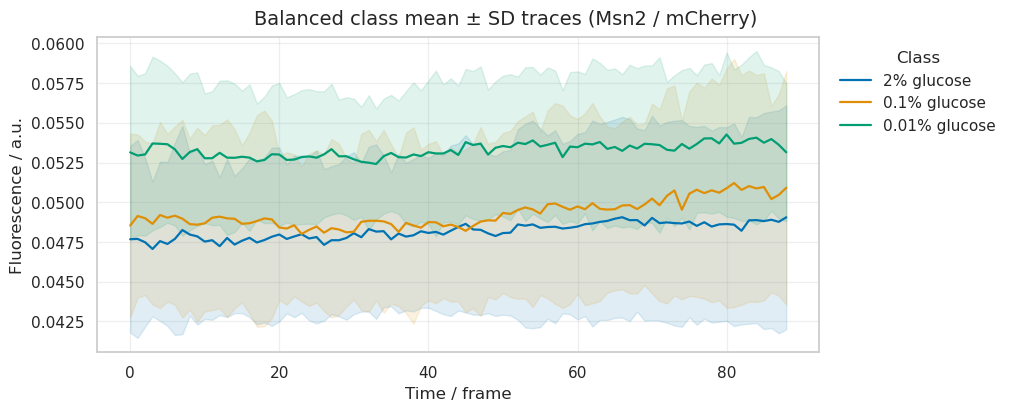

In [15]:
class_names_bal = [label_names[i] for i in sorted(label_names)]
palette = sns.color_palette("colorblind", n_colors=len(class_names_bal))
n_tp = X_bal.shape[1]

fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
for lbl, class_name in enumerate(class_names_bal):
    mask = y_bal == lbl
    mean = X_bal[mask].mean(axis=0)
    sd = X_bal[mask].std(axis=0, ddof=1)
    color = palette[lbl]
    ax.plot(np.arange(n_tp), mean, label=class_name, color=color, linewidth=1.6)
    ax.fill_between(np.arange(n_tp), mean - sd, mean + sd, color=color, alpha=0.12)

ax.set_xlabel("Time / frame")
ax.set_ylabel("Fluorescence / a.u.")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, title="Class")
fig.suptitle("Balanced class mean ± SD traces (Msn2 / mCherry)", fontsize=14)
fig_path = IY021_DIR / "IY021_mcherry_catch22_balanced_class_traces.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()


## 3. Raw SVM (RBF) – Time Series as Features

In [16]:
print("=== Raw SVM (RBF) ===")

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
])

svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

class_names = [label_names[i] for i in sorted(label_names)]
print(f"Raw SVM Accuracy: {svm_acc:.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=class_names))

=== Raw SVM (RBF) ===
Raw SVM Accuracy: 0.6429

               precision    recall  f1-score   support

   2% glucose       0.59      0.72      0.65        32
 0.1% glucose       0.60      0.36      0.45        33
0.01% glucose       0.72      0.85      0.78        33

     accuracy                           0.64        98
    macro avg       0.64      0.64      0.63        98
 weighted avg       0.64      0.64      0.63        98



## 4. Catch22 + SVM (RBF) – Hand-crafted Features

In [17]:
from features.catch22 import extract_catch22

from utils.processing.feature_frames import fit_fill_feature_frame


print("Extracting Catch22 features (train)...")
X_train_c22 = extract_catch22(X_train, desc="Train")
print("Extracting Catch22 features (test)...")
X_test_c22  = extract_catch22(X_test,  desc="Test")

X_train_c22, X_test_c22 = fit_fill_feature_frame(X_train_c22, X_test_c22)

print(f"\nCatch22 feature matrix: {X_train_c22.shape[1]} features")

print("\n=== Catch22 + SVM (RBF) ===")
c22_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
])
c22_pipe.fit(X_train_c22, y_train)
y_pred_c22 = c22_pipe.predict(X_test_c22)
c22_acc = accuracy_score(y_test, y_pred_c22)

print(f"Catch22 + SVM Accuracy: {c22_acc:.4f}")
print()
class_names = [label_names[i] for i in sorted(label_names)]
print(classification_report(y_test, y_pred_c22, target_names=class_names))

Extracting Catch22 features (train)...


Extracting Catch22 features (test)...



Catch22 feature matrix: 22 features



=== Catch22 + SVM (RBF) ===
Catch22 + SVM Accuracy: 0.6327

               precision    recall  f1-score   support

   2% glucose       0.65      0.53      0.59        32
 0.1% glucose       0.58      0.58      0.58        33
0.01% glucose       0.67      0.79      0.72        33

     accuracy                           0.63        98
    macro avg       0.63      0.63      0.63        98
 weighted avg       0.63      0.63      0.63        98



## 5. Results Comparison

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_mCherry_catch22_results.csv


,model,accuracy
0,Raw SVM (RBF),0.642857
1,catch22 + SVM (RBF),0.632653


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_mCherry_svm_vs_catch22.png


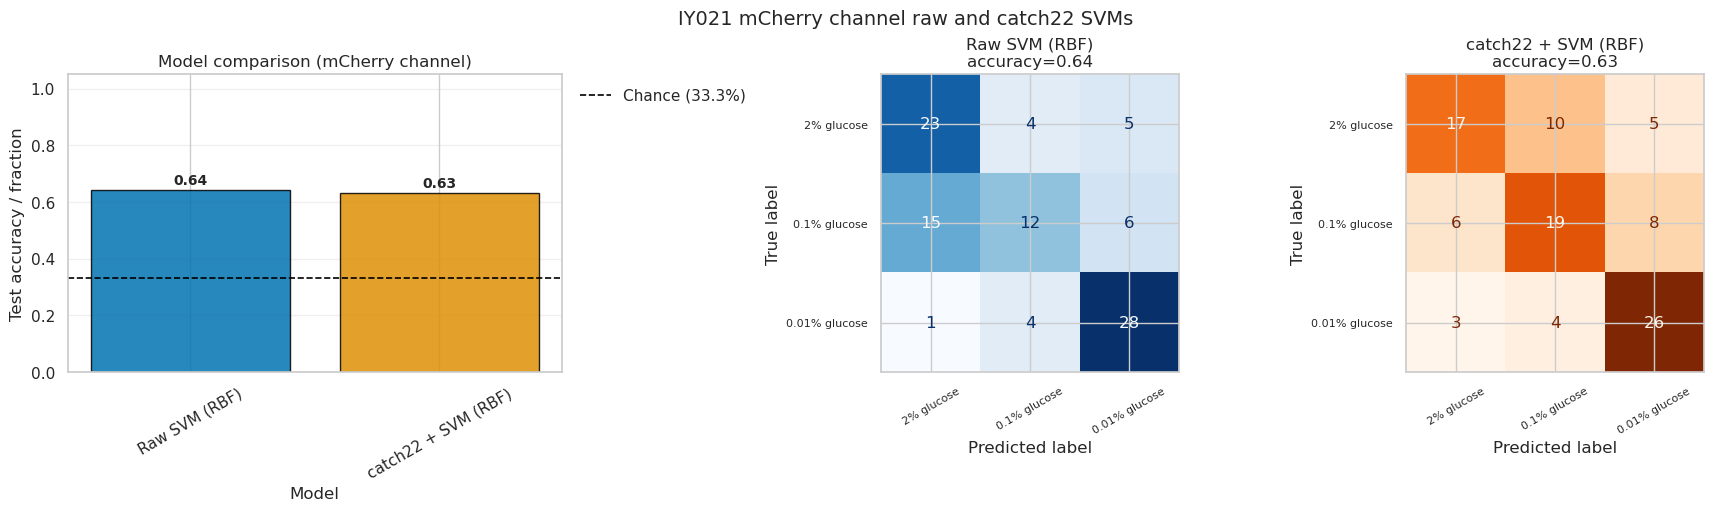


=== Summary ===
  Chance level        : 0.3333
  Raw SVM (RBF)         : 0.6429
  catch22 + SVM (RBF)   : 0.6327
  Winner: Raw SVM (RBF) (+0.0102)


In [18]:
class_names = [label_names[i] for i in sorted(label_names)]
chance = 1 / len(label_names)

summary_df = pd.DataFrame([
    {"model": "Raw SVM (RBF)", "accuracy": svm_acc},
    {"model": "catch22 + SVM (RBF)", "accuracy": c22_acc},
]).sort_values("accuracy", ascending=False).reset_index(drop=True)

results_path = IY021_DIR / "IY021_mCherry_catch22_results.csv"
summary_df.to_csv(results_path, index=False)
print(f"Saved: {results_path}")
display(summary_df)

predictions = {
    "Raw SVM (RBF)": y_pred_svm,
    "catch22 + SVM (RBF)": y_pred_c22,
}
cmaps = {
    "Raw SVM (RBF)": "Blues",
    "catch22 + SVM (RBF)": "Oranges",
}
colors = {
    "Raw SVM (RBF)": sns.color_palette("colorblind")[0],
    "catch22 + SVM (RBF)": sns.color_palette("colorblind")[1],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
bars = axes[0].bar(
    summary_df["model"],
    summary_df["accuracy"],
    color=[colors[m] for m in summary_df["model"]],
    alpha=0.85,
    edgecolor="black",
)
axes[0].axhline(chance, color="black", linestyle="--", linewidth=1.2, label=f"Chance ({chance:.1%})")
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Test accuracy / fraction")
axes[0].set_title("Model comparison (mCherry channel)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
axes[0].grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, summary_df["accuracy"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.2f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

for ax, (_, row) in zip(axes[1:], summary_df.iterrows()):
    model_name = row["model"]
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[model_name],
        display_labels=class_names,
        ax=ax,
        colorbar=False,
        cmap=cmaps[model_name],
        xticks_rotation=30,
    )
    ax.set_title(f"{model_name}\naccuracy={row['accuracy']:.2f}")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("IY021 mCherry channel raw and catch22 SVMs", fontsize=14)
fig_path = IY021_DIR / "IY021_mCherry_svm_vs_catch22.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

print("\n=== Summary ===")
print(f"  Chance level        : {chance:.4f}")
for _, row in summary_df.iterrows():
    print(f"  {row['model']:<22s}: {row['accuracy']:.4f}")
print(f"  Winner: {summary_df.iloc[0]['model']} (+{summary_df.iloc[0]['accuracy'] - summary_df.iloc[-1]['accuracy']:.4f})")